# 02. Расчет MDE и размера выборки

## Содержание
1. [Экономическое обоснование MDE](#экономическое-обоснование-mde)
2. [Расчет размера выборки](#расчет-размера-выборки)
3. [Сравнение сценариев](#сравнение-сценариев)
4. [Выводы](#выводы)

## Загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('..')
from src.data_loader import load_economic_data
from src.stats import calculate_sample_size
from src.metrics import calculate_mde_economic
from src.visualizations import plot_sample_size_vs_mde

df_economic = load_economic_data()
print(f"Загружено {len(df_economic)} строк")

Загружено 26 строк


## Экономическое обоснование MDE

In [2]:
# Текущие показатели
current_revenue_per_week = df_economic['revenue'].mean()
current_ctr = df_economic['ctr'].mean()
current_aov = df_economic['avg_order_value'].mean()

# Параметры
development_cost = 600000  # 600 тыс. руб
payback_months = 6
current_monthly_revenue = current_revenue_per_week * 4

print("Текущие показатели бизнеса\n")
print(f"  Выручка в неделю: {current_revenue_per_week:,.0f} руб")
print(f"  Выручка в месяц: {current_monthly_revenue:,.0f} руб")
print(f"  Текущий CTR: {current_ctr:.2%}")
print(f"  Средний чек: {current_aov:,.0f} руб")

Текущие показатели бизнеса

  Выручка в неделю: 500,056 руб
  Выручка в месяц: 2,000,223 руб
  Текущий CTR: 7.66%
  Средний чек: 3,581 руб


In [3]:
# Расчет MDE
mde_result = calculate_mde_economic(
    development_cost=development_cost,
    payback_months=payback_months,
    current_monthly_revenue=current_monthly_revenue,
    ctr_elasticity=0.85,
    buffer=1.2
)

print("Расчет экономически обоснованного MDE\n")
print(f"1. Затраты на разработку: {development_cost:,.0f} руб")
print(f"2. Период окупаемости: {payback_months} месяцев")
print(f"3. Требуемый прирост в месяц: {mde_result['required_monthly_growth']:,.0f} руб")
print(f"4. Необходимый прирост выручки: {mde_result['required_growth_pct_pct']:.2f}%")
print(f"5. Эластичность выручки по CTR: {mde_result['ctr_elasticity']:.2f}")
print(f"6. MDE (без запаса): {mde_result['mde_pct']:.2f}%")
print(f"7. MDE (с запасом 20%): {mde_result['mde_with_buffer_pct']:.2f}%")

Расчет экономически обоснованного MDE

1. Затраты на разработку: 600,000 руб
2. Период окупаемости: 6 месяцев
3. Требуемый прирост в месяц: 100,000 руб
4. Необходимый прирост выручки: 5.00%
5. Эластичность выручки по CTR: 0.85
6. MDE (без запаса): 5.88%
7. MDE (с запасом 20%): 7.06%


### Итоговый MDE

> **MDE = 20%** (экономически обоснованный, с запасом)

**Интерпретация:**
- Если прирост CTR ≥ 20% → разработка окупается за 6 месяцев
- Если прирост CTR < 20% → разработка экономически нецелесообразна

## Расчет размера выборки

In [4]:
# Параметры
BASELINE_CTR = 0.078
MDE = 0.20
ALPHA = 0.05
POWER = 0.90

# Расчет для одностороннего теста
n_one = calculate_sample_size(BASELINE_CTR, MDE, ALPHA, POWER, one_sided=True)
n_two = calculate_sample_size(BASELINE_CTR, MDE, ALPHA, POWER, one_sided=False)

# Сравнение
print("Сравнение одностороннего и двухстороннего теста\n")
comparison_data = {
    'Параметр': ['Z_α', 'Размер выборки (на группу)', 'Общая выборка', 'Длительность (дней)'],
    'Двухсторонний': [
        f'{n_two["z_alpha"]:.3f}',
        f'{n_two["n_per_group"]:,}',
        f'{n_two["n_total"]:,}',
        f'{n_two["days"]}'
    ],
    'Односторонний': [
        f'{n_one["z_alpha"]:.3f}',
        f'{n_one["n_per_group"]:,}',
        f'{n_one["n_total"]:,}',
        f'{n_one["days"]}'
    ]
}

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))

Сравнение одностороннего и двухстороннего теста

                  Параметр Двухсторонний Односторонний
                       Z_α         1.960         1.645
Размер выборки (на группу)         6,774         5,521
             Общая выборка        13,548        11,042
       Длительность (дней)            83            68


In [5]:
# Сравнение при разных MDE
print("Сравнение размера выборки при разных MDE\n")

mde_values = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]
results_comparison = []

for mde in mde_values:
    res = calculate_sample_size(BASELINE_CTR, mde, ALPHA, POWER, one_sided=True)
    results_comparison.append({
        'MDE': f"{res['mde_rel']:.0f}%",
        'MDE (абс.)': f"{res['mde_abs']*100:.2f} п.п.",
        'CTR в тесте': f"{res['test_rate']*100:.2f}%",
        'N (на группу)': f"{res['n_per_group']:,}",
        'N (всего)': f"{res['n_total']:,}",
        'Дней': f"{res['days']}"
    })

df_comparison = pd.DataFrame(results_comparison)
print(df_comparison.to_string(index=False))

Сравнение размера выборки при разных MDE

MDE MDE (абс.) CTR в тесте N (на группу) N (всего) Дней
10%  0.78 п.п.       8.58%        21,169    42,338  259
15%  1.17 п.п.       8.97%         9,612    19,224  118
20%  1.56 п.п.       9.36%         5,521    11,042   68
25%  1.95 п.п.       9.75%         3,606     7,212   44
30%  2.34 п.п.      10.14%         2,555     5,110   32
40%  3.12 п.п.      10.92%         1,493     2,986   19
50%  3.90 п.п.      11.70%           991     1,982   13


In [6]:
# Влияние мощности
print("Влияние мощности на размер выборки\n")

power_values = [0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
power_results = []

for power in power_values:
    res = calculate_sample_size(BASELINE_CTR, MDE, ALPHA, power, one_sided=True)
    power_results.append({
        'Мощность': f"{res['power']*100:.0f}%",
        'Z_β': f"{res['z_beta']:.3f}",
        'N (на группу)': f"{res['n_per_group']:,}",
        'N (всего)': f"{res['n_total']:,}",
        'Дней': f"{res['days']}"
    })

df_power = pd.DataFrame(power_results)
print(df_power.to_string(index=False))

Влияние мощности на размер выборки

Мощность   Z_β N (на группу) N (всего) Дней
     70% 0.524         3,034     6,068   37
     75% 0.674         3,468     6,936   43
     80% 0.842         3,986     7,972   49
     85% 1.036         4,635     9,270   57
     90% 1.282         5,521    11,042   68
     95% 1.645         6,977    13,954   86


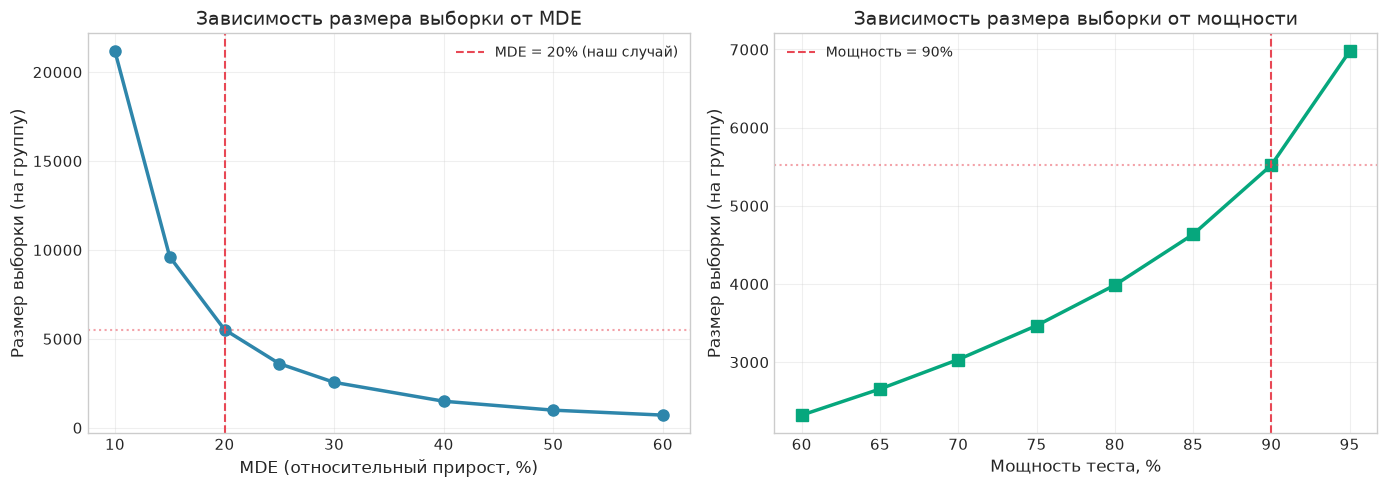

In [8]:
# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: MDE vs Sample Size
mdes = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50, 0.60]
ns = [calculate_sample_size(BASELINE_CTR, m, ALPHA, POWER, one_sided=True)['n_per_group'] for m in mdes]

axes[0].plot([m*100 for m in mdes], ns, 'o-', color='#2E86AB', linewidth=2.5, markersize=8)
axes[0].axvline(20, color='#E84855', linestyle='--', label='MDE = 20% (наш случай)')
axes[0].axhline(n_one['n_per_group'], color='#E84855', linestyle=':', alpha=0.5)
axes[0].set_xlabel('MDE (относительный прирост, %)')
axes[0].set_ylabel('Размер выборки (на группу)')
axes[0].set_title('Зависимость размера выборки от MDE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# График 2: Power vs Sample Size
powers = [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
n_power = [calculate_sample_size(BASELINE_CTR, MDE, ALPHA, p, one_sided=True)['n_per_group'] for p in powers]

axes[1].plot([p*100 for p in powers], n_power, 's-', color='#06A77D', linewidth=2.5, markersize=8)
axes[1].axvline(90, color='#E84855', linestyle='--', label='Мощность = 90%')
axes[1].axhline(n_one['n_per_group'], color='#E84855', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Мощность теста, %')
axes[1].set_ylabel('Размер выборки (на группу)')
axes[1].set_title('Зависимость размера выборки от мощности')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Выводы

### Итоговые параметры эксперимента

| Параметр | Значение |
|----------|----------|
| **Тип теста** | Односторонний (right-tailed) |
| **MDE** | 20% |
| **Мощность** | 90% |
| **Уровень значимости** | 5% |
| **Выборка (на группу)** | 5,521 пользователей |
| **Общая выборка** | 11,042 пользователей |
| **Длительность** | 68 дней (при 82 открытиях/день) |

### Обоснование выбора

1. **Односторонний тест** — экономит ~16% выборки
2. **MDE = 20%** — экономически обоснован, окупаемость за 6 месяцев
3. **Power = 90%** — высокий уровень надежности
4. **68 дней** — приемлемый срок для бизнеса